In [2]:
import os
from dotenv import load_dotenv

found = load_dotenv()
print("`.env` file found and loaded:", found)
print("Current working directory:", os.getcwd())

# List every key currently loaded from .env, without printing the actual password
for key in ["DB_USER", "DB_PASSWORD", "DB_HOST", "DB_NAME"]:
    print(key, "=", os.getenv(key))

`.env` file found and loaded: True
Current working directory: C:\Dev\india-air-quality-intel\notebooks
DB_USER = None
DB_PASSWORD = None
DB_HOST = None
DB_NAME = None


In [3]:
env_path = r"C:\Dev\india-air-quality-intel\.env"

with open(env_path) as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith("#"):
            key = line.split("=")[0]
            print(key)

DATA_GOV_IN_API_KEY
579b464db66ec23bdd000001e8906a579e904a12568528a89e31c6cb
OPENAQ_API_KEY
MYSQL_HOST
MYSQL_PORT
MYSQL_USER
MYSQL_PASSWORD
MYSQL_DATABASE
MYSQL_USER
MYSQL_PASSWORD


In [4]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv(dotenv_path=r"C:\Dev\india-air-quality-intel\.env", override=True)

db_host = os.getenv("MYSQL_HOST")
db_port = os.getenv("MYSQL_PORT")
db_user = os.getenv("MYSQL_USER")
db_password = os.getenv("MYSQL_PASSWORD")
db_name = os.getenv("MYSQL_DATABASE")

print("Connecting as user:", db_user)   # sanity check — should print 'aqi_loader', not 'root'

engine = create_engine(f"mysql+mysqlconnector://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")

df_check = pd.read_sql("SELECT COUNT(*) AS row_count FROM fact_kaggle_historical;", engine)
print(df_check)

Connecting as user: aqi_loader
   row_count
0    1140696


In [5]:
query = """
SELECT
    f.daily_aqi_id,
    f.station_id,
    s.station_name,
    s.source_station_key,
    c.city_name,
    f.reading_date,
    f.aqi_value,
    f.aqi_bucket,
    f.flag_missing
FROM fact_kaggle_daily_aqi f
JOIN dim_station s ON f.station_id = s.station_id
JOIN dim_city c ON s.city_id = c.city_id
WHERE s.source_system = 'kaggle';
"""

df_daily = pd.read_sql(query, engine)
print("Total rows:", len(df_daily))
print(df_daily["city_name"].value_counts())

Total rows: 95058
city_name
Delhi        45360
Bengaluru    11996
Hyderabad     8752
Chennai       6406
Lucknow       6099
Mumbai        5504
Kolkata       3165
Jaipur        3089
Patna         2678
Ahmedabad     2009
Name: count, dtype: int64


In [6]:
coverage = df_daily.groupby("city_name")["reading_date"].agg(
    first_date="min",
    last_date="max",
    days_with_data="nunique"
).sort_values("days_with_data", ascending=False)

print(coverage)

           first_date   last_date  days_with_data
city_name                                        
Ahmedabad  2015-01-01  2020-07-01            2009
Bengaluru  2015-01-01  2020-07-01            2009
Chennai    2015-01-01  2020-07-01            2009
Delhi      2015-01-01  2020-07-01            2009
Mumbai     2015-01-01  2020-07-01            2009
Lucknow    2015-01-01  2020-07-01            2009
Hyderabad  2015-01-04  2020-07-01            2006
Patna      2015-06-01  2020-07-01            1858
Jaipur     2017-06-14  2020-07-01            1114
Kolkata    2018-04-10  2020-07-01             814


year       2015  2016  2017   2018   2019  2020
city_name                                      
Ahmedabad   365   366   365    365    365   183
Bengaluru   837  1464  1460   2755   3650  1830
Chennai    1095  1098  1095   1095   1291   732
Delhi      3268  3994  5098  12358  13870  6772
Hyderabad   483   854  1937   2190   2190  1098
Jaipur        0     0   350   1095   1095   549
Kolkata       0     0     0    322   1562  1281
Lucknow     730   732   851   1460   1593   733
Mumbai      365   366   365    365   2213  1830
Patna       214   366   365    365    389   979


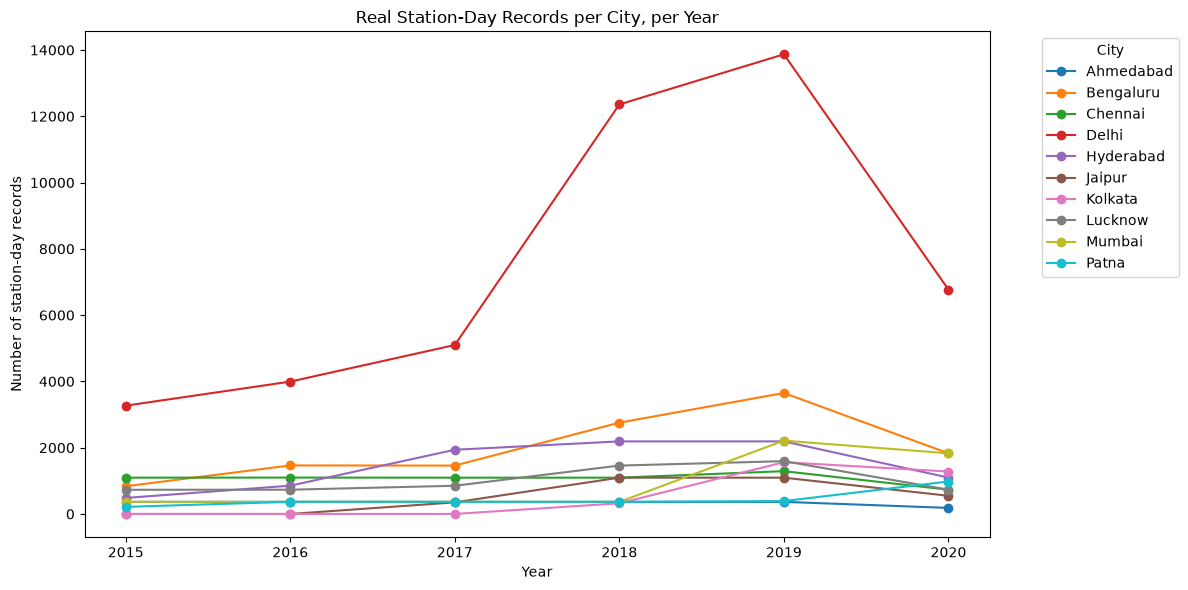

In [7]:
df_daily['reading_date'] = pd.to_datetime(df_daily['reading_date'])
df_daily['year'] = df_daily['reading_date'].dt.year

coverage_by_year = df_daily.groupby(['city_name', 'year']).size().unstack(fill_value=0)
print(coverage_by_year)

import matplotlib.pyplot as plt

coverage_by_year.T.plot(kind='line', marker='o', figsize=(12, 6))
plt.title("Real Station-Day Records per City, per Year")
plt.ylabel("Number of station-day records")
plt.xlabel("Year")
plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
stations_per_year = df_daily.groupby(['city_name', 'year'])['station_id'].nunique().unstack(fill_value=0)
print(stations_per_year)

year       2015  2016  2017  2018  2019  2020
city_name                                    
Ahmedabad     1     1     1     1     1     1
Bengaluru     4     4     4    10    10    10
Chennai       3     3     3     3     4     4
Delhi        10    12    18    38    38    38
Hyderabad     2     3     6     6     6     6
Jaipur        0     0     3     3     3     3
Kolkata       0     0     0     2     7     7
Lucknow       2     2     4     4     5     5
Mumbai        1     1     1     1    10    10
Patna         1     1     1     1     4     6


In [9]:
total_years = df_daily['year'].nunique()
station_year_counts = df_daily.groupby('station_id')['year'].nunique()

stable_stations = station_year_counts[station_year_counts == total_years].index
print(f"Total years in dataset: {total_years}")
print(f"Stations present in ALL {total_years} years: {len(stable_stations)}")

df_stable = df_daily[df_daily['station_id'].isin(stable_stations)]
print("\nStable stations per city:")
print(df_stable.groupby('city_name')['station_id'].nunique())

Total years in dataset: 6
Stations present in ALL 6 years: 24

Stable stations per city:
city_name
Ahmedabad     1
Bengaluru     4
Chennai       3
Delhi        10
Hyderabad     2
Lucknow       2
Mumbai        1
Patna         1
Name: station_id, dtype: int64


Rows flagged missing: 0
Rows where aqi_value is actually NaN: 18898
      All Stations (naive)  Stable 10 Stations Only
year                                               
2015            302.315883               302.315883
2016            298.956323               294.158429
2017            326.073822               370.967480
2018            246.323843               256.474713
2019            232.024836               236.270503
2020            183.495207               181.644960


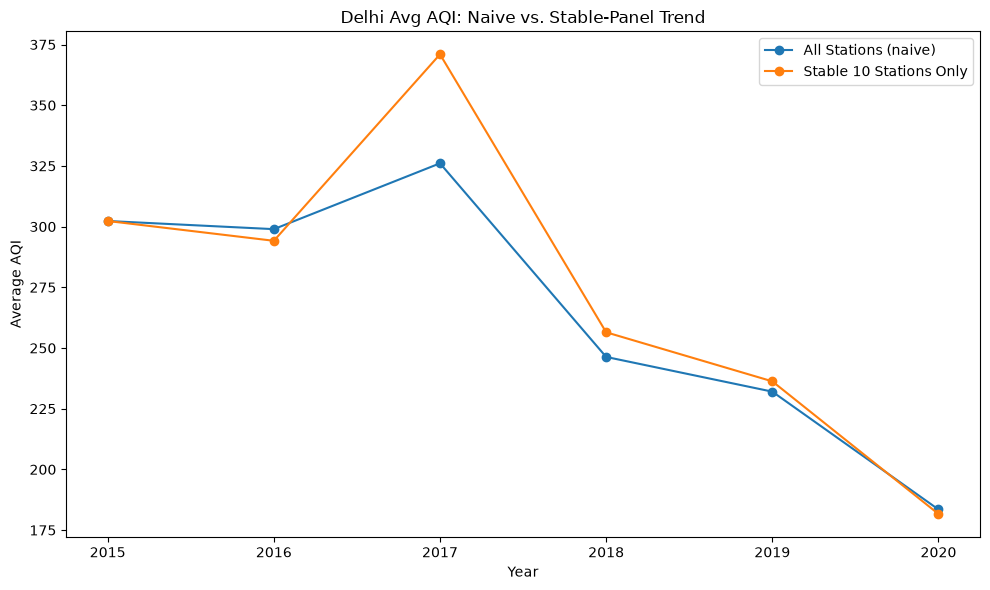

In [10]:
# Safety check: does flag_missing line up with real NaN values?
print("Rows flagged missing:", df_daily['flag_missing'].astype(str).str.lower().eq('true').sum())
print("Rows where aqi_value is actually NaN:", df_daily['aqi_value'].isna().sum())

# Naive trend: every station, every year
naive_delhi = df_daily[df_daily['city_name'] == 'Delhi'].groupby('year')['aqi_value'].mean()

# Stable trend: only the 10 Delhi stations present in all 6 years
stable_delhi = df_stable[df_stable['city_name'] == 'Delhi'].groupby('year')['aqi_value'].mean()

comparison = pd.DataFrame({'All Stations (naive)': naive_delhi, 'Stable 10 Stations Only': stable_delhi})
print(comparison)

comparison.plot(kind='line', marker='o', figsize=(10, 6), title="Delhi Avg AQI: Naive vs. Stable-Panel Trend")
plt.ylabel("Average AQI")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [11]:
print("dtype:", df_daily['flag_missing'].dtype)
print("unique values:", df_daily['flag_missing'].unique())

dtype: int64
unique values: [1 0]


In [12]:
print("Rows flagged missing (corrected):", (df_daily['flag_missing'] == 1).sum())
print("Rows where aqi_value is actually NaN:", df_daily['aqi_value'].isna().sum())

Rows flagged missing (corrected): 18898
Rows where aqi_value is actually NaN: 18898


month
1     358.111300
2     284.921053
3     214.111399
4     236.697262
5     243.279106
6     205.337490
7     150.894318
8     135.253538
9     153.403468
10    301.475463
11    387.495726
12    373.825044
Name: aqi_value, dtype: float64


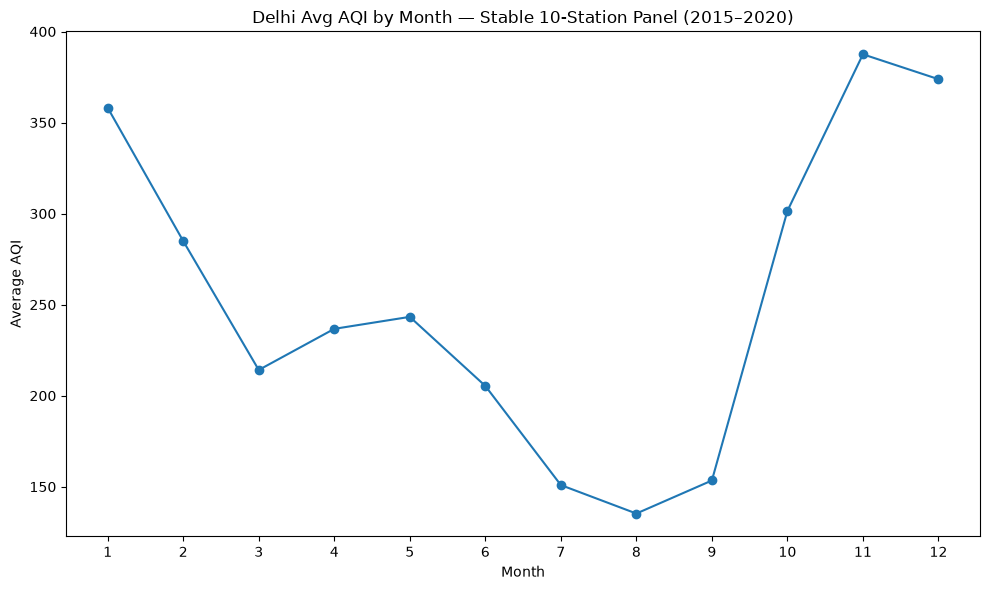

In [13]:
df_stable['month'] = df_stable['reading_date'].dt.month

delhi_stable = df_stable[df_stable['city_name'] == 'Delhi']
monthly_avg = delhi_stable.groupby('month')['aqi_value'].mean()

print(monthly_avg)

monthly_avg.plot(kind='line', marker='o', figsize=(10, 6),
                  title="Delhi Avg AQI by Month — Stable 10-Station Panel (2015–2020)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

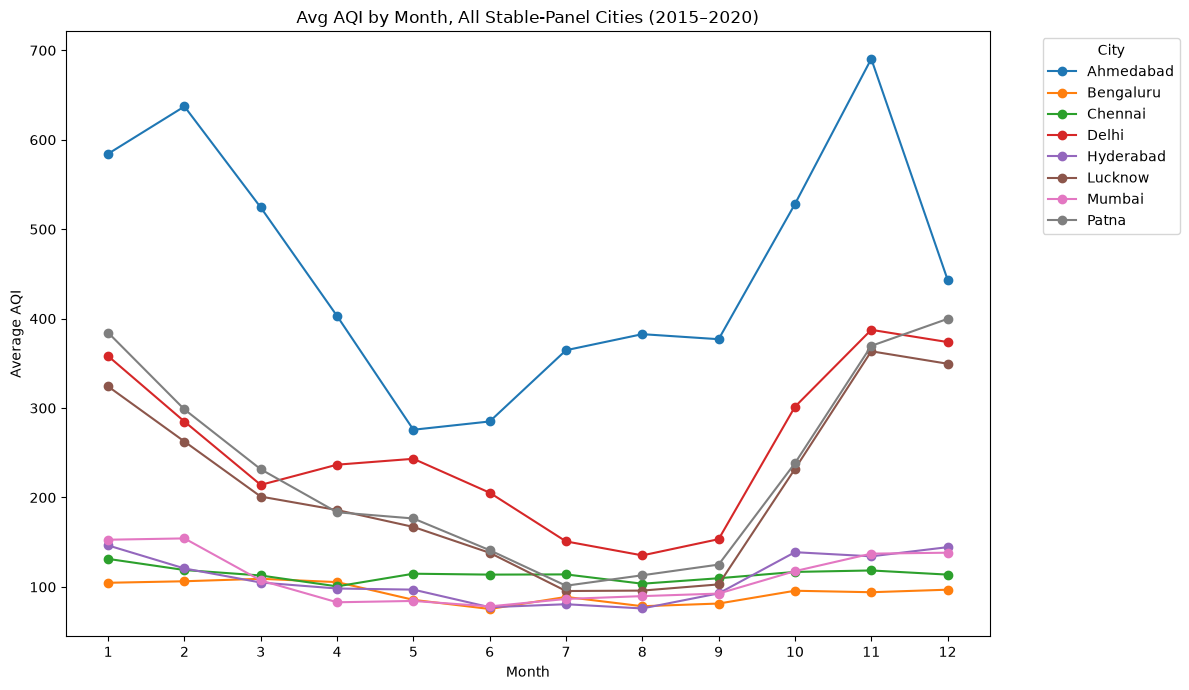

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

for city in df_stable['city_name'].unique():
    city_data = df_stable[df_stable['city_name'] == city]
    monthly = city_data.groupby('month')['aqi_value'].mean()
    ax.plot(monthly.index, monthly.values, marker='o', label=city)

ax.set_title("Avg AQI by Month, All Stable-Panel Cities (2015–2020)")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
ax.set_xticks(range(1, 13))
ax.legend(title="City", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
ahmedabad_stable = df_stable[df_stable['city_name'] == 'Ahmedabad']
print(ahmedabad_stable[['station_id', 'station_name', 'source_station_key']].drop_duplicates())
print("\nAhmedabad AQI stats:")
print(ahmedabad_stable['aqi_value'].agg(['mean', 'max', 'min']))

   station_id                 station_name source_station_key
0         199  Maninagar, Ahmedabad - GPCB              GJ001

Ahmedabad AQI stats:
mean     452.122939
max     2049.000000
min       48.000000
Name: aqi_value, dtype: float64


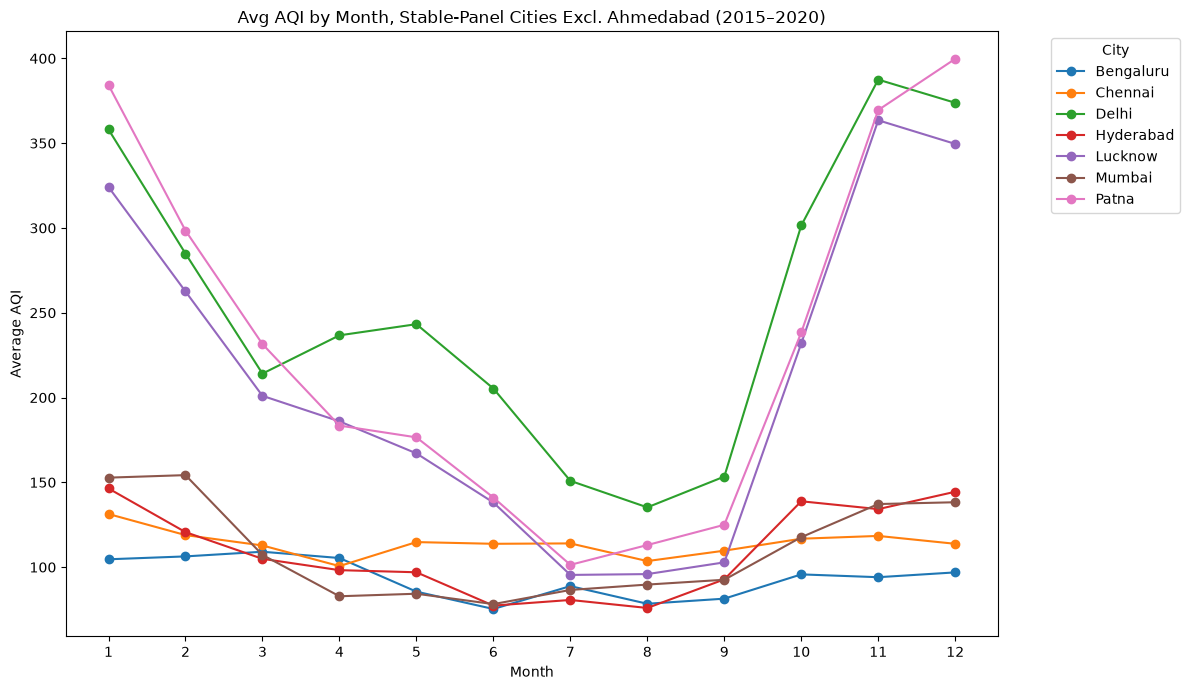

In [16]:
cities_to_plot = [c for c in df_stable['city_name'].unique() if c != 'Ahmedabad']

fig, ax = plt.subplots(figsize=(12, 7))

for city in cities_to_plot:
    city_data = df_stable[df_stable['city_name'] == city]
    monthly = city_data.groupby('month')['aqi_value'].mean()
    ax.plot(monthly.index, monthly.values, marker='o', label=city)

ax.set_title("Avg AQI by Month, Stable-Panel Cities Excl. Ahmedabad (2015–2020)")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
ax.set_xticks(range(1, 13))
ax.legend(title="City", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


Full calendar days in range: 2009
Real missing days (no data at all): 114


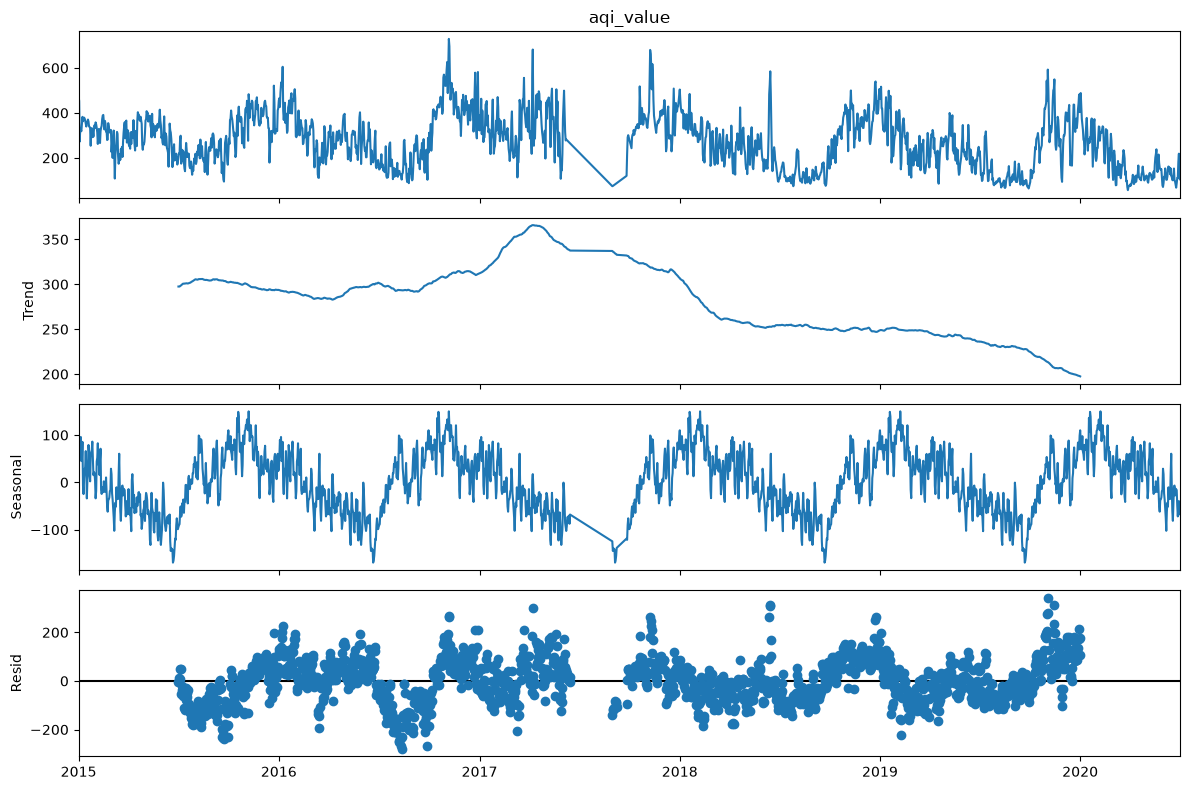

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate Delhi's 10 stable stations into one city-level daily average
delhi_daily = delhi_stable.groupby('reading_date')['aqi_value'].mean().sort_index()

# Reindex onto a full, continuous daily calendar to expose any real gaps
full_range = pd.date_range(delhi_daily.index.min(), delhi_daily.index.max(), freq='D')
delhi_daily = delhi_daily.reindex(full_range)

print("Full calendar days in range:", len(full_range))
print("Real missing days (no data at all):", delhi_daily.isna().sum())

# Interpolate small gaps so decomposition can run — documented, not hidden
delhi_daily_filled = delhi_daily.interpolate(limit=7)

result = seasonal_decompose(delhi_daily_filled.dropna(), model='additive', period=365)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [19]:
# Find the length of every consecutive run of missing days
is_missing = delhi_daily.isna()
gap_lengths = []
current_gap = 0

for missing in is_missing:
    if missing:
        current_gap += 1
    else:
        if current_gap > 0:
            gap_lengths.append(current_gap)
        current_gap = 0
if current_gap > 0:
    gap_lengths.append(current_gap)

gap_lengths.sort(reverse=True)
print("Longest gaps (days):", gap_lengths[:10])
print("Number of gaps longer than 7 days:", sum(1 for g in gap_lengths if g > 7))

Longest gaps (days): [83, 24, 5, 1, 1]
Number of gaps longer than 7 days: 2


In [20]:
# Locate the real calendar dates of each gap
gap_starts = []
in_gap = False
gap_start_date = None

for date, is_na in delhi_daily.isna().items():
    if is_na and not in_gap:
        in_gap = True
        gap_start_date = date
    elif not is_na and in_gap:
        in_gap = False
        gap_starts.append((gap_start_date, date, (date - gap_start_date).days))

gap_starts.sort(key=lambda x: -x[2])
print("Largest real gaps (start, end-of-gap, length in days):")
for g in gap_starts[:5]:
    print(g)

Largest real gaps (start, end-of-gap, length in days):
(Timestamp('2017-06-09 00:00:00'), Timestamp('2017-08-31 00:00:00'), 83)
(Timestamp('2017-09-02 00:00:00'), Timestamp('2017-09-26 00:00:00'), 24)
(Timestamp('2017-09-30 00:00:00'), Timestamp('2017-10-05 00:00:00'), 5)
(Timestamp('2016-07-24 00:00:00'), Timestamp('2016-07-25 00:00:00'), 1)
(Timestamp('2017-04-23 00:00:00'), Timestamp('2017-04-24 00:00:00'), 1)


In [21]:
delhi_daily_df = delhi_daily.to_frame(name='aqi_value')
delhi_daily_df['year'] = delhi_daily_df.index.year
delhi_daily_df['month'] = delhi_daily_df.index.month

# Check 1: is monsoon-season missing data concentrated in 2017 specifically?
monsoon = delhi_daily_df[delhi_daily_df['month'].isin([6, 7, 8, 9])]
missing_pct_by_year = monsoon.groupby('year')['aqi_value'].apply(lambda x: x.isna().mean() * 100)
print("% of Jun-Sep days missing, by year:")
print(missing_pct_by_year)

# Check 2: recompute yearly averages EXCLUDING monsoon months for every year equally
non_monsoon = delhi_daily_df[~delhi_daily_df['month'].isin([6, 7, 8, 9])]
yearly_non_monsoon_avg = non_monsoon.groupby('year')['aqi_value'].mean()
print("\nYearly avg AQI, Jun-Sep excluded from ALL years (fair comparison):")
print(yearly_non_monsoon_avg)

% of Jun-Sep days missing, by year:
year
2015     0.000000
2016     0.819672
2017    88.524590
2018     0.000000
2019     0.000000
2020     0.000000
Name: aqi_value, dtype: float64

Yearly avg AQI, Jun-Sep excluded from ALL years (fair comparison):
year
2015    335.741863
2016    357.220570
2017    353.553893
2018    305.654835
2019    283.006470
2020    191.511641
Name: aqi_value, dtype: float64


Months with no data at all: 1


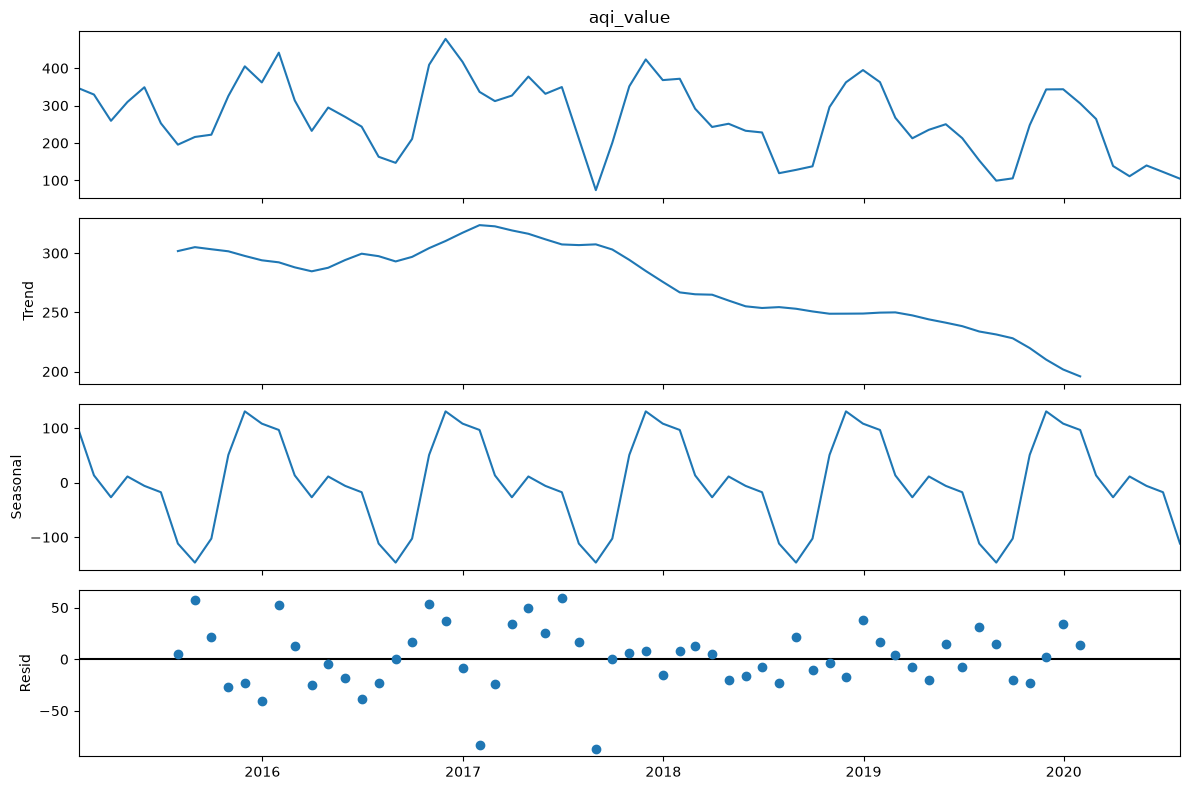

In [22]:
delhi_monthly = delhi_daily_df.groupby(pd.Grouper(freq='ME')).mean()['aqi_value']

print("Months with no data at all:", delhi_monthly.isna().sum())
delhi_monthly_filled = delhi_monthly.interpolate(limit=2)

result_monthly = seasonal_decompose(delhi_monthly_filled.dropna(), model='additive', period=12)
fig = result_monthly.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [23]:
for city in [c for c in df_stable['city_name'].unique() if c != 'Ahmedabad']:
    city_data = df_stable[df_stable['city_name'] == city]
    city_daily = city_data.groupby('reading_date')['aqi_value'].mean()
    full_range = pd.date_range(city_daily.index.min(), city_daily.index.max(), freq='D')
    city_daily = city_daily.reindex(full_range)
    
    monsoon_2017 = city_daily[(city_daily.index.year == 2017) & (city_daily.index.month.isin([6,7,8,9]))]
    pct_missing = monsoon_2017.isna().mean() * 100
    print(f"{city}: {pct_missing:.1f}% of Jun-Sep 2017 missing")

Bengaluru: 0.8% of Jun-Sep 2017 missing
Chennai: 3.3% of Jun-Sep 2017 missing
Delhi: 88.5% of Jun-Sep 2017 missing
Hyderabad: 100.0% of Jun-Sep 2017 missing
Lucknow: 2.5% of Jun-Sep 2017 missing
Mumbai: 100.0% of Jun-Sep 2017 missing
Patna: 100.0% of Jun-Sep 2017 missing


In [24]:
for city in ['Hyderabad', 'Mumbai', 'Patna']:
    city_data = df_stable[df_stable['city_name'] == city].copy()
    city_data['year'] = city_data['reading_date'].dt.year
    city_data['month'] = city_data['reading_date'].dt.month

    naive_yearly = city_data.groupby('year')['aqi_value'].mean()

    non_monsoon = city_data[~city_data['month'].isin([6,7,8,9])]
    fair_yearly = non_monsoon.groupby('year')['aqi_value'].mean()

    print(f"\n--- {city} ---")
    print("Naive yearly avg:\n", naive_yearly)
    print("Monsoon-excluded (fair) yearly avg:\n", fair_yearly)


--- Hyderabad ---
Naive yearly avg:
 year
2015    146.695652
2016    135.088571
2017    130.993056
2018     98.063422
2019    102.611028
2020     80.525641
Name: aqi_value, dtype: float64
Monsoon-excluded (fair) yearly avg:
 year
2015    153.651064
2016    133.290909
2017    130.993056
2018    114.974576
2019    123.182222
2020     90.312253
Name: aqi_value, dtype: float64

--- Mumbai ---
Naive yearly avg:
 year
2015           NaN
2016           NaN
2017           NaN
2018    102.612335
2019    114.697059
2020     85.697674
Name: aqi_value, dtype: float64
Monsoon-excluded (fair) yearly avg:
 year
2015           NaN
2016           NaN
2017           NaN
2018    129.324074
2019    121.551111
2020     94.087379
Name: aqi_value, dtype: float64

--- Patna ---
Naive yearly avg:
 year
2015    350.555556
2016    252.326284
2017    326.368056
2018    233.634349
2019    219.796657
2020    233.178218
Name: aqi_value, dtype: float64
Monsoon-excluded (fair) yearly avg:
 year
2015    350.555556
201

In [25]:
mumbai_stable = df_stable[df_stable['city_name'] == 'Mumbai'].copy()
mumbai_stable['year'] = mumbai_stable['reading_date'].dt.year

print(mumbai_stable.groupby('year').agg(
    total_rows=('aqi_value', 'size'),
    real_values=('aqi_value', 'count'),   # .count() skips NaN automatically
    pct_missing=('flag_missing', 'mean')
))

      total_rows  real_values  pct_missing
year                                      
2015         365            0     1.000000
2016         366            0     1.000000
2017         365            0     1.000000
2018         365          227     0.378082
2019         365          340     0.068493
2020         183          129     0.295082


In [26]:
summary = df_stable.copy()
summary['year'] = summary['reading_date'].dt.year

pivot = summary.groupby(['city_name', 'year']).agg(
    total_rows=('aqi_value', 'size'),
    real_values=('aqi_value', 'count')
).reset_index()

pivot['pct_real'] = (pivot['real_values'] / pivot['total_rows'] * 100).round(1)

pivot_table = pivot.pivot(index='city_name', columns='year', values='pct_real')
print(pivot_table)

year       2015  2016  2017  2018  2019   2020
city_name                                     
Ahmedabad  72.1  32.0  18.9  97.8  96.4   96.2
Bengaluru  73.6  62.8  68.9  75.9  82.7   82.9
Chennai    68.3  68.8  46.5  85.7  91.1   98.9
Delhi      51.4  40.4  27.0  95.3  98.5   96.5
Hyderabad  76.2  47.8  19.7  92.9  91.9   85.2
Lucknow    72.3  85.7  91.5  66.3  99.0  100.0
Mumbai      0.0   0.0   0.0  62.2  93.2   70.5
Patna      37.9  90.4  39.5  98.9  98.4   55.2


In [27]:
for city, year in [('Lucknow', 2018), ('Patna', 2020)]:
    city_data = df_stable[(df_stable['city_name'] == city) & (df_stable['reading_date'].dt.year == year)].copy()
    city_data['month'] = city_data['reading_date'].dt.month
    monthly_completeness = city_data.groupby('month').agg(
        total=('aqi_value', 'size'),
        real=('aqi_value', 'count')
    )
    monthly_completeness['pct_real'] = (monthly_completeness['real'] / monthly_completeness['total'] * 100).round(1)
    print(f"\n--- {city} {year}, by month ---")
    print(monthly_completeness)


--- Lucknow 2018, by month ---
       total  real  pct_real
month                       
1         62    59      95.2
2         56    27      48.2
3         62     0       0.0
4         60     0       0.0
5         62     0       0.0
6         60    33      55.0
7         62    61      98.4
8         62    62     100.0
9         60    60     100.0
10        62    62     100.0
11        60    60     100.0
12        62    60      96.8

--- Patna 2020, by month ---
       total  real  pct_real
month                       
1         31    31     100.0
2         29    24      82.8
3         31    26      83.9
4         30    10      33.3
5         31     0       0.0
6         30     9      30.0
7          1     1     100.0


In [28]:
city_coords = pd.read_sql("SELECT city_name, latitude, longitude FROM dim_city WHERE city_name = 'Delhi';", engine)
print(city_coords)

  city_name  latitude  longitude
0     Delhi   28.6139     77.209


In [29]:
import requests

lat = city_coords.loc[0, 'latitude']
lon = city_coords.loc[0, 'longitude']

start_date = delhi_daily.index.min().strftime('%Y-%m-%d')
end_date = delhi_daily.index.max().strftime('%Y-%m-%d')

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": start_date,
    "end_date": end_date,
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max",
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
print("Status code:", response.status_code)

weather_json = response.json()
weather_df = pd.DataFrame(weather_json['daily'])
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df = weather_df.set_index('time')

print("Rows fetched:", len(weather_df))
print(weather_df.head())

Status code: 200
Rows fetched: 2009
            temperature_2m_max  temperature_2m_min  precipitation_sum  \
time                                                                    
2015-01-01                21.3                12.0                0.0   
2015-01-02                17.2                14.2                4.2   
2015-01-03                17.9                14.0                0.1   
2015-01-04                19.1                10.9                0.0   
2015-01-05                20.7                 9.6                0.0   

            windspeed_10m_max  
time                           
2015-01-01                8.9  
2015-01-02               11.2  
2015-01-03                9.0  
2015-01-04               13.5  
2015-01-05               27.0  


Rows after matching on real overlapping dates: 2009
temperature_2m_min   -0.477001
precipitation_sum    -0.278647
temperature_2m_max   -0.267477
windspeed_10m_max    -0.210168
aqi_value             1.000000
Name: aqi_value, dtype: float64


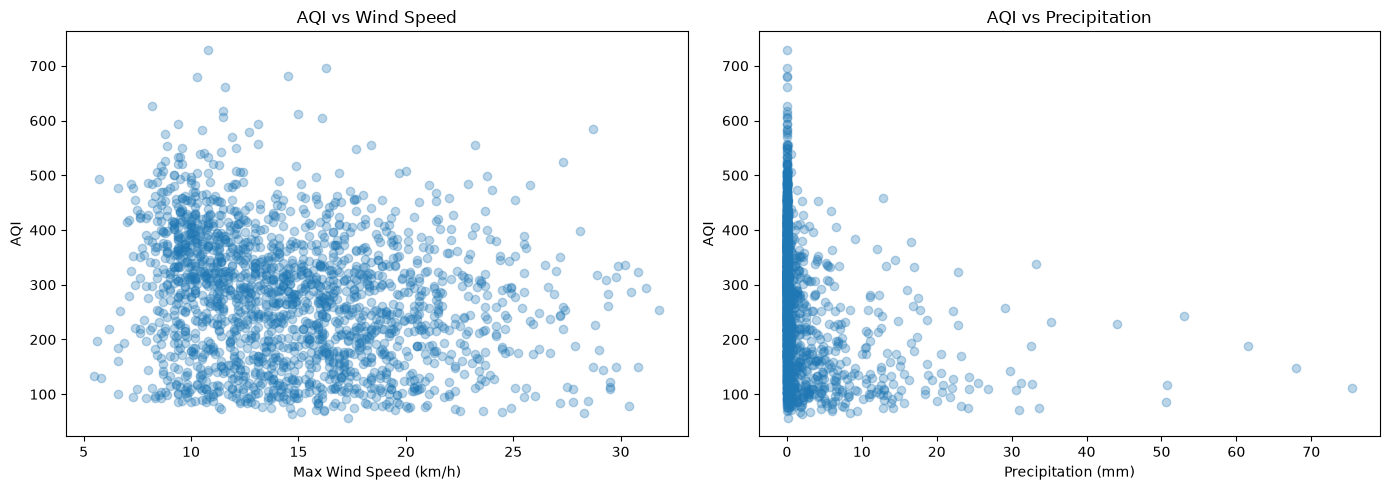

In [30]:
merged = delhi_daily.to_frame(name='aqi_value').join(weather_df, how='inner')
print("Rows after matching on real overlapping dates:", len(merged))

correlation = merged.corr(numeric_only=True)['aqi_value'].sort_values()
print(correlation)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(merged['windspeed_10m_max'], merged['aqi_value'], alpha=0.3)
axes[0].set_xlabel("Max Wind Speed (km/h)")
axes[0].set_ylabel("AQI")
axes[0].set_title("AQI vs Wind Speed")

axes[1].scatter(merged['precipitation_sum'], merged['aqi_value'], alpha=0.3)
axes[1].set_xlabel("Precipitation (mm)")
axes[1].set_ylabel("AQI")
axes[1].set_title("AQI vs Precipitation")
plt.tight_layout()
plt.show()

In [31]:
merged['month'] = merged.index.month
winter_only = merged[merged['month'].isin([11, 12, 1])]

print("Winter-only rows:", len(winter_only))
print(winter_only.corr(numeric_only=True)['aqi_value'].sort_values())

Winter-only rows: 491
windspeed_10m_max    -0.278609
precipitation_sum    -0.137765
month                 0.147905
temperature_2m_min    0.163761
temperature_2m_max    0.363999
aqi_value             1.000000
Name: aqi_value, dtype: float64
